# Project - Modern Los Angeles Sunday

## 1 - Importing Libraries

In [941]:
import pandas as pd
import numpy as np               
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns            
from scipy import stats
from IPython.display import display
import textwrap
from scipy.stats import mannwhitneyu

## 2 - Loading Data

### 2.1 - Importing dataframes

In [942]:
data = pd.read_csv('../data/rest_data_us_upd.csv')

### 2.2 - Data Description

In this project, we work with a market analysis to analyze the investment in a modern cafeteria in Los Angeles, where there will be stolen waiters as a differential. The goal is to collect data, analyze and present to seek new investors for the coffee shop.


The dataframe data:

object_name - name of establishment  
chain - networking (TRUE/FALSE)  
object_type - type of establishment  
address - address  
number - number of seats

### 2.3 - Preparing the Data

#### 2.3.1 - Checking for null values, missing values, data types, and data structure size.

In [943]:
# Running info() to understand our df.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9651 entries, 0 to 9650
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           9651 non-null   int64 
 1   object_name  9651 non-null   object
 2   address      9651 non-null   object
 3   chain        9648 non-null   object
 4   object_type  9651 non-null   object
 5   number       9651 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 452.5+ KB


In [944]:
# Displaying dataframe on display for better visualization.
display(data.head())

,id,object_name,address,chain,object_type,number
0,11786,HABITAT COFFEE SHOP,3708 N EAGLE ROCK BLVD,False,Cafe,26
1,11787,REILLY'S,100 WORLD WAY 120,False,Restaurant,9
2,11788,STREET CHURROS,6801 HOLLYWOOD BLVD 253,False,Fast Food,20
3,11789,TRINITI ECHO PARK,1814 W SUNSET BLVD,False,Restaurant,22
4,11790,POLLEN,2100 ECHO PARK AVE,False,Restaurant,20


In [945]:
# Searching for null values.
data.isnull().sum()
# Since it's only 3 rows, we will remove the rows with null values.
data = data.dropna()
# It was found various incorrect names of establishments in the 'object_name' column where there were # and a sequential identification number for more precise calculation purposes, we will remove the # and the subsequent numbers keeping only the establishment name.
patterns = {r'\s*#\s*\d+': '',r'.*STARBUCKS.*': 'STARBUCKS',r'.*SUBWAY.*': 'SUBWAY',r'.*THE KITCHEN.*': 'THE KITCHEN',r'.*MC\s*DONALD[’\']?S.*': 'MCDONALDS',
    r'.*MCDONALD.*': 'MCDONALDS',r'.*BURGER\s+KING.*': 'BURGER KING',r'.*\bKFC\b.*': 'KFC',r'.*PANDA\s+EXPRESS.*': 'PANDA EXPRESS',
    r'.*OUMI\s+SUSHI.*': 'OUMI SUSHI',r'.*YUM\s+YUM\s+DONUTS\s+FRANCHISE.*': 'YUM YUM DONUTS FRANCHISE',r'.*LAS\s+CHAMPAS.*': 'LAS CHAMPAS'}

In [946]:
# Searching for the duplicate values.
print('The number of duplicates is', data.duplicated().sum())

The number of duplicates is 0


All the dataframe information was checked, it has 3 null values representing 0.031% of all the data, so they were removed for more precise analysis, no duplicate row was found.  
All columns are already in lowercase and in the correct string and integer data types.

## 5 - Data Exploratory Analysis

In [947]:
display(data.sample(10))

,id,object_name,address,chain,object_type,number
8522,20308,CHINA EXPRESS,8522 S WESTERN AVE B,True,Fast Food,18
9024,20810,JAMBA JUICE #1514,4729 VENICE BLVD,True,Restaurant,43
237,12023,OLYMPIC CAFE HOUSE OF BKFST,3728 W OLYMPIC BLVD,False,Restaurant,5
6265,18051,MEDIA SERVICES CAFE,500 S SEPULVEDA BLVD 1FL,False,Restaurant,2
3818,15604,YEE'S CHINESE FOOD,4400 W SLAUSON AVE,True,Restaurant,46
6164,17950,PHILLIPS B B Q,4307 LEIMERT BLVD,False,Restaurant,1
1713,13499,PHO FAMILY RESTAURANT,1025 N STATE ST,True,Restaurant,48
4645,16431,NORMANDIE CLUB,3612 W 6TH ST,False,Restaurant,144
6501,18287,BLUE BOTTLE COFFEE,1712 W SUNSET BLVD,True,Cafe,34
4032,15818,NAMSAN,3613 W 6TH ST B,False,Restaurant,38


### 5.1 - Investigate the proportions of various types of establishments. Construct a graph.

In [948]:
type_unique = (data.groupby('object_type').size().reset_index(name='quantity').sort_values(by='quantity', ascending=False))
total_type = type_unique['quantity'].sum()
type_unique['percentual'] = ((type_unique['quantity'] / total_type) * 100).round(2)
type_unique = type_unique.sort_values(by='percentual', ascending=False)

type_unique.head(10)

,object_type,quantity,percentual
5,Restaurant,7253,75.18
3,Fast Food,1066,11.05
2,Cafe,435,4.51
4,Pizza,319,3.31
1,Bar,292,3.03
0,Bakery,283,2.93


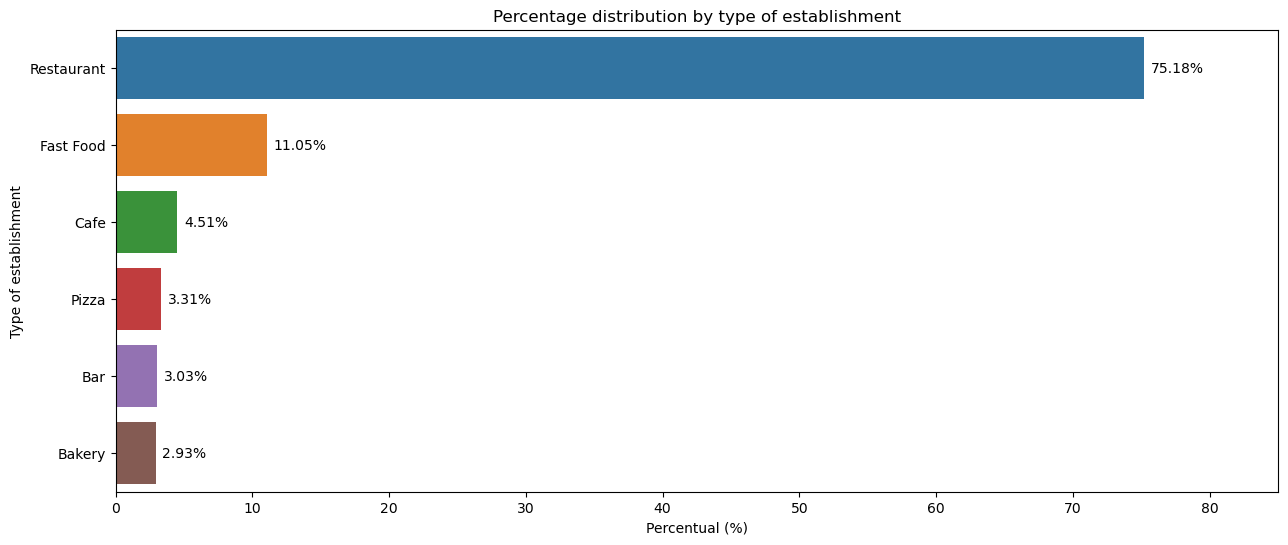

In [949]:
plt.figure(figsize=(15, 6))
ax = sns.barplot(data=type_unique,x='percentual',y='object_type')

plt.title('Percentage distribution by type of establishment')
plt.xlabel('Percentual (%)')
plt.ylabel('Type of establishment')
plt.xlim(0, 85)

for i, v in enumerate(type_unique['percentual']):
    ax.text(v + 0.5, i, f'{v:.2f}%', va='center')

plt.show()


The graph shows that restaurants largely dominate the chains, accounting for about 75% of establishments.  
Fast food appears as the second most common type, with just over 11%, while cafes, pizzerias, bars and bakeries have individual participation below 5%.  
This indicates that the networks strongly concentrate their operations in traditional restaurant formats, with less diversification among other types of establishments.

### 5.2 - Investigate the proportions of network and non-network establishments. Construct a graph.

In [950]:
network_comparison = data['chain'].value_counts()
network_comparison = (data['chain'].value_counts().reset_index().rename(columns={'index': 'chain', 'chain': 'quantity'}))
network_total = network_comparison['quantity'].sum()
network_comparison['percentual'] = (network_comparison['quantity'] / network_total * 100).round(2)
network_comparison['chain'] = network_comparison['chain'].replace({True: 'Yes',False: 'No'})

print(network_comparison)

  chain  quantity  percentual
0    No      5972        61.9
1   Yes      3676        38.1


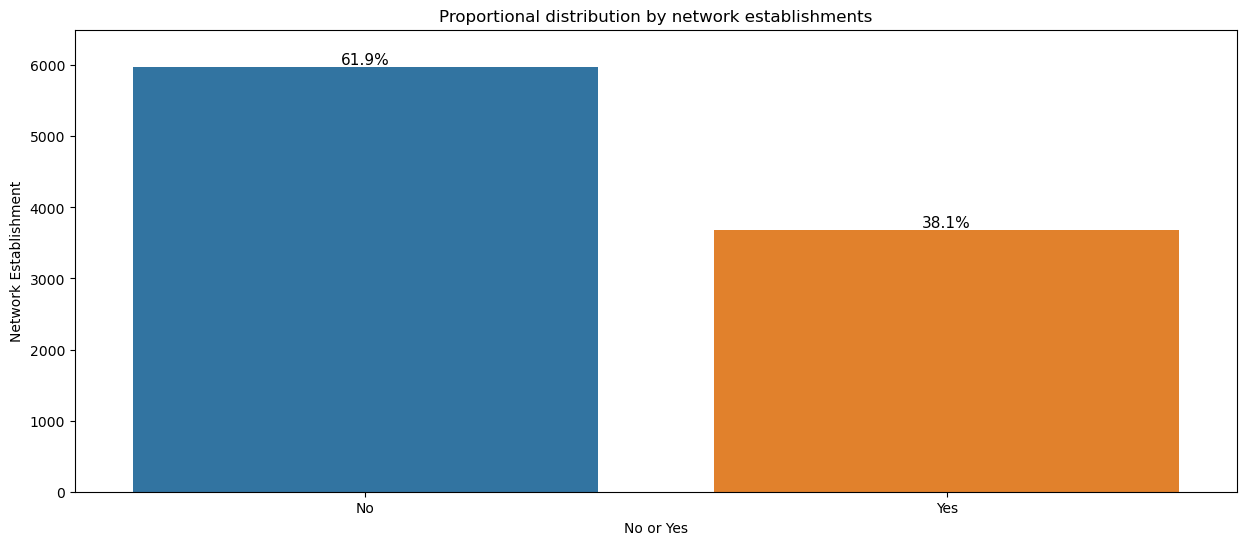

In [951]:
plt.figure(figsize=(15, 6))
ax = sns.barplot(data=network_comparison,y='quantity',x='chain')

plt.title('Proportional distribution by network establishments')
plt.xlabel('No or Yes')
plt.ylabel('Network Establishment')
plt.ylim(0,6500)

for p, pct in zip(ax.patches, network_comparison['percentual']):ax.annotate(f'{pct:.1f}%',(p.get_x() + p.get_width() / 2, p.get_height()),ha='center',va='bottom',fontsize=11)

plt.show()

From the graph above we can see that the number of network establishments in the city of Los Angeles is significant with 38.1% of all who own in the city, almost half if we stop to analyze.

### 5.3 - What type of establishment is typical for networks?

In [952]:
network_types = data[data['chain']== True]
network_types = network_types['object_type'].value_counts()
network_types = (network_types.reset_index().rename(columns={'index': 'object_type', 'object_type': 'quantity'}))
network_types['percentual'] = ((network_types['quantity'] / network_types['quantity'].sum()) * 100).round(2)

network_types.head()

,object_type,quantity,percentual
0,Restaurant,2292,62.35
1,Fast Food,605,16.46
2,Bakery,283,7.70
3,Cafe,266,7.24
4,Pizza,153,4.16


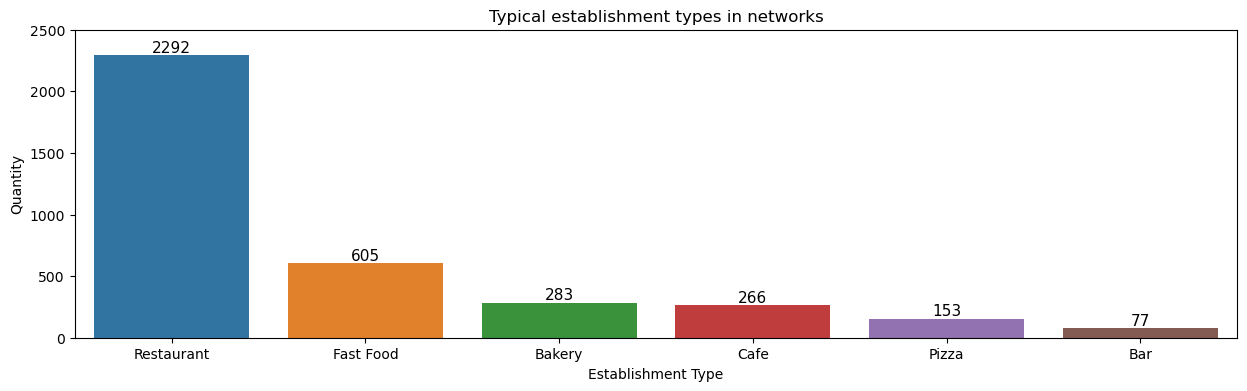

In [953]:
plt.figure(figsize=(15,4))
ax=sns.barplot(data=network_types,x='object_type',y='quantity')

plt.title('Typical establishment types in networks')
plt.xlabel('Establishment Type')
plt.ylabel('Quantity')
plt.ylim(0,2500)

for p, valor in zip(ax.patches, network_types['quantity']):ax.annotate(f'{valor}',(p.get_x() + p.get_width() / 2, p.get_height()),ha='center',va='bottom',fontsize=11)

plt.show()

The graph shows that restaurants are by far the most common type of establishment among chains, followed by fast food.  
Types like bakery, coffee and pizza appear less frequently, while bars are underrepresented.  
These results indicate that the networks concentrate their operations mainly in traditional restaurant and fast food formats, which favor greater standardization and scale.

### 5.4 - What characterizes networks: many establishments with a small number of seats or few establishments with many seats?

In [954]:
network_yes = data[data['chain'] == True].copy()
network_yes['qtd_object'] = (network_yes.groupby('object_name')['object_name'].transform('count'))
network_yes[['object_name', 'qtd_object']].drop_duplicates().sample(10)
networks_df = (network_yes.groupby('object_name').agg(qtd_establishments=('qtd_object', 'first'),medium_seats=('number', 'mean'),median_seats=('number', 'median')).reset_index())

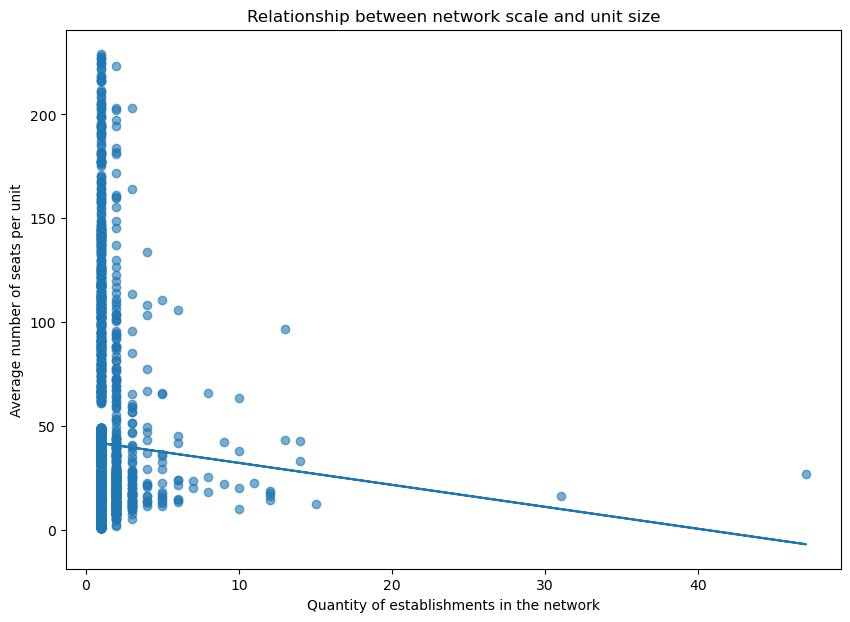

In [955]:
x = networks_df['qtd_establishments']
y = networks_df['medium_seats']

coef = np.polyfit(x, y, 1)
trend = np.poly1d(coef)

plt.figure(figsize=(10,7))
plt.scatter(x, y, alpha=0.6)
plt.plot(x, trend(x))

plt.xlabel('Quantity of establishments in the network')
plt.ylabel('Average number of seats per unit')
plt.title('Relationship between network scale and unit size')

plt.show()

Network scale vs unit size

The scatter graph shows that networks with few units have great variability in average number of seats.  
However, as the number of establishments in the network increases, values tend to concentrate on smaller units.  
The negative slope of the trend line indicates that the networks are characterized mainly by many establishments with few seats, and not by a few large establishments.

### 5.5 - Determine the average number of seats for each type of restaurant. On average, which type of restaurant has the most seats? Build graphics.

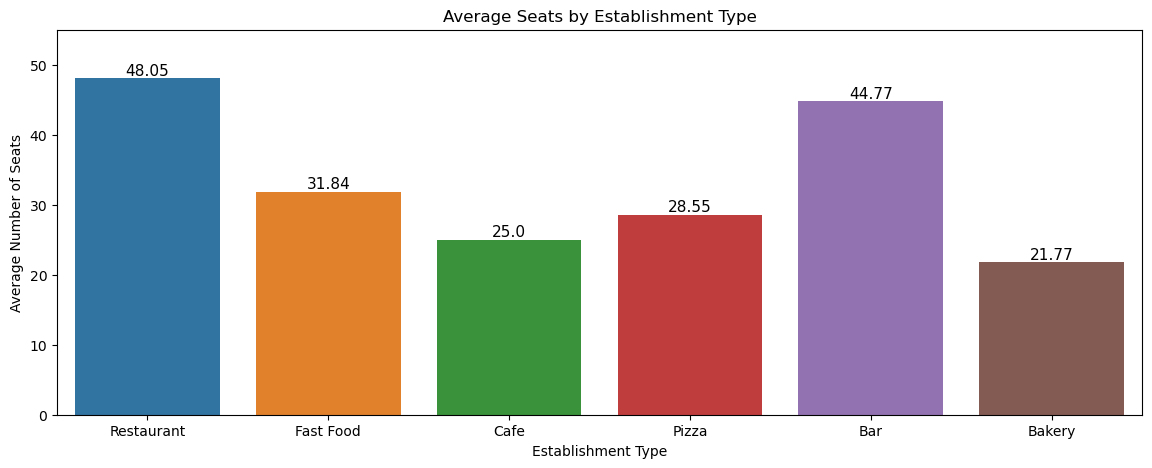

In [956]:
network_type_mean_seat = (data.groupby('object_type').agg(quantity=('object_type','count'), total_seats=('number','sum'), medium_seats=('number','mean')).reset_index().sort_values(by='quantity', ascending=False))
network_type_mean_seat['medium_seats'] = network_type_mean_seat['medium_seats'].round(2)

plt.figure(figsize=(14,5))
ax = sns.barplot(data=network_type_mean_seat,y='medium_seats',x='object_type')
plt.xlabel('Establishment Type')
plt.ylabel('Average Number of Seats')
plt.title('Average Seats by Establishment Type')
plt.ylim(0,55)

for p, valor in zip(ax.patches, network_type_mean_seat['medium_seats']):ax.annotate(f'{valor}',(p.get_x() + p.get_width() / 2, p.get_height()),ha='center',va='bottom',fontsize=11)

plt.show()

The graph shows that restaurants and bars have the largest averages of seats, indicating larger establishments.  
In contrast, cafes and bakeries have the smallest averages, characterizing more compact units.  
The types fast food and pizza occupy an intermediate position, suggesting standardized formats with moderate size.

### 5.6 - Put the street name data of the address column in a separate column.

In [957]:
data = data.copy()
data['street_name'] = (data['address'].str.upper().str.replace(r'^\d+\s+[NSEW]\s+', '', regex=True)
    .str.replace(r'^\d+\s+', '', regex=True).str.replace(r'\s+(STE|UNIT|APT|SUITE|#).*$', '', regex=True).str.replace(r'\s+\d+$', '', regex=True).str.strip())

data.head()

,id,object_name,address,chain,object_type,number,street_name
0,11786,HABITAT COFFEE SHOP,3708 N EAGLE ROCK BLVD,False,Cafe,26,EAGLE ROCK BLVD
1,11787,REILLY'S,100 WORLD WAY 120,False,Restaurant,9,WORLD WAY
2,11788,STREET CHURROS,6801 HOLLYWOOD BLVD 253,False,Fast Food,20,HOLLYWOOD BLVD
3,11789,TRINITI ECHO PARK,1814 W SUNSET BLVD,False,Restaurant,22,SUNSET BLVD
4,11790,POLLEN,2100 ECHO PARK AVE,False,Restaurant,20,ECHO PARK AVE


### 5.7 - Build a ten-street chart with the most restaurants.

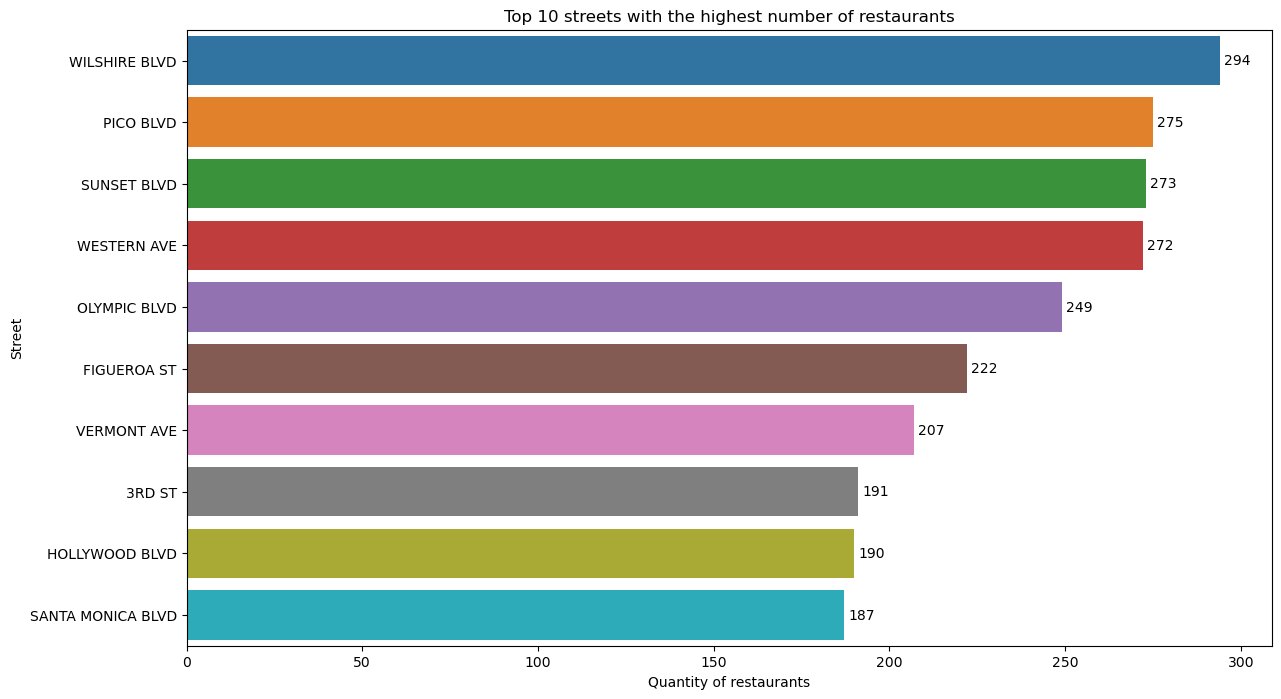

In [958]:
# Applying filter to the 10 streets with the highest number of restaurants.
restaurants = data[data['object_type'] == 'Restaurant']
top10street = (restaurants['street_name'].value_counts().head(10).reset_index())
top10street.columns = ['street_name', 'quantity']

plt.figure(figsize=(14,8))

ax = sns.barplot(data=top10street,x='quantity',y='street_name')

plt.xlabel('Quantity of restaurants')
plt.ylabel('Street')
plt.title('Top 10 streets with the highest number of restaurants')

# labels at the top of the bars
for p in ax.patches:ax.annotate(
        int(p.get_width()),(p.get_width(), p.get_y() + p.get_height() / 2),va='center',ha='left',xytext=(3, 0),textcoords='offset points')

plt.show()

The graph shows that Wilshire Blvd, Pico Blvd and Sunset Blvd concentrate the largest number of restaurants, standing out as important gastronomic corridors in the city.  
The other streets in the ranking also have a high concentration of establishments, indicating that the gastronomic activity in Los Angeles is organized along large avenues, which offer greater visibility, flow of people and accessibility.

### 5.8 - Find the number of streets that have only one restaurant.

In [959]:
streets_one_restaurant = (data[data['object_type'] == 'Restaurant'].groupby('street_name').size().reset_index(name='quantity'))
num_streets_one_restaurant = streets_one_restaurant[streets_one_restaurant['quantity'] == 1].shape[0]

print('There are ',num_streets_one_restaurant,' streets with only 1 restaurant scattered throughout the city.')

There are  594  streets with only 1 restaurant scattered throughout the city.


The number of streets that have only one restaurant was identified, indicating areas with low concentration of gastronomic establishments.  
This result contrasts with the gastronomic corridors previously observed, where there is a large concentration of restaurants in a few streets.

### 5.9 - For streets with many restaurants, look at the seating distribution. What trends can you spot?

In [960]:
top_streets = top10street['street_name']
restaurants_top_streets = data[(data['object_type'] == 'Restaurant') &(data['street_name'].isin(top_streets))]

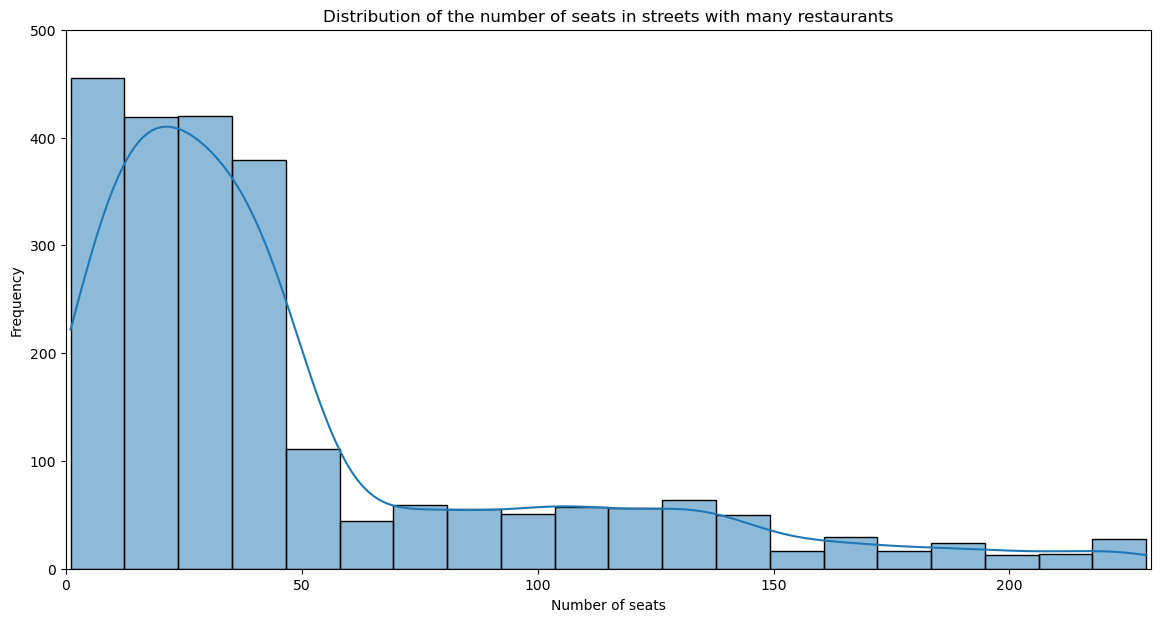

In [961]:
plt.figure(figsize=(14,7))
sns.histplot(restaurants_top_streets['number'], bins=20, kde=True)
plt.xlabel('Number of seats')
plt.ylabel('Frequency')
plt.title('Distribution of the number of seats in streets with many restaurants')
plt.xlim(0,230)
plt.ylim(0,500)
plt.show()


The distribution presents a strong concentration of restaurants with low to medium number of seats, mainly up to about 50 places, as well as a long tail on the right, indicating few large establishments.  
This pattern suggests that streets with many restaurants tend to concentrate several smaller establishments rather than a few large ones, favoring greater density and gastronomic diversity.

### 6 - General Conclusion

From the analysis of data from food establishments in Los Angeles, it was possible to identify clear patterns related to the structure of the gastronomic market, the spatial distribution of restaurants and the scale strategies adopted by establishments.

The results show that the sector is largely dominated by traditional restaurants, which represent the majority of establishments both in absolute quantity and percentage share. Other types, such as fast food, cafes, bakeries, pizzerias and bars, appear in smaller proportions, indicating that the restaurant format remains the main operating model of the city. However, when analyzing the average seats by type, it is observed that restaurants and bars tend to have greater capacity, while cafes and bakeries operate mostly in smaller spaces, reflecting clear differences of profile and consumption proposal.

The spatial analysis revealed a strong concentration of restaurants on large avenues, such as Wilshire Blvd, Pico Blvd and Sunset Blvd, which stand out as true gastronomic corridors. These streets concentrate hundreds of establishments, while a large number of streets have only one single restaurant, evidencing an uneven and highly centralized distribution of the gastronomic activity in the city.

When specifically investigating the streets with the largest number of restaurants, it was observed that high density is not associated with large restaurants but rather with the presence of many small and medium-sized establishments. The distribution of seating in these streets is asymmetric, with a strong concentration on low values and a long tail to the right, indicating that few very large restaurants coexist with a majority of compact units. This pattern suggests that the dominant strategy in these gastronomic corridors is based on multiplicity of units, favoring diversity, rotation and use of urban space.

Overall, the gastronomic landscape of Los Angeles can be characterized by high spatial concentration, predominance of smaller establishments, and scale models based on quantity and standardization, especially in areas of large flow. These results provide a consistent view of the urban and commercial dynamics of the sector, which can serve as a basis for strategic expansion decisions, market studies and analyses on urban planning and use of space in the city.

## 6 - Presentation

Here is the link to the presentation: [https://drive.google.com/file/d/1BDJ3nhrFMPgE9_pG2l9axR-WH10JI64Q/view?usp=sharing]